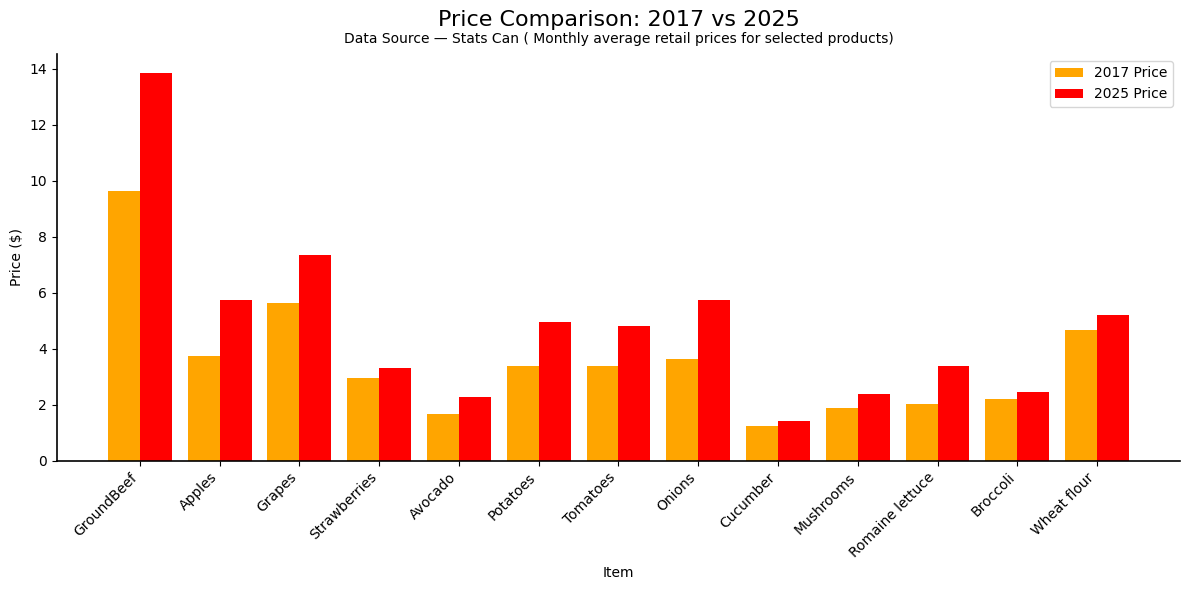

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the Excel file
item_price_diff_df = pd.read_excel("HamburgerItemPriceDiffFrom2017to2025.xlsx", sheet_name="Sheet1")

# Extract data
items = item_price_diff_df['Item']
price_2017 = item_price_diff_df['Price_2017']
price_2025 = item_price_diff_df['Price_2025']

# Create bar chart
plt.figure(figsize=(12, 6), facecolor='white')

x = range(len(items))

# Plot bars with colors
plt.bar(x, price_2017, width=0.4, label='2017 Price', align='center', color='orange')
plt.bar([i + 0.4 for i in x], price_2025, width=0.4, label='2025 Price', align='center', color='red')

# Main title
plt.title('Price Comparison: 2017 vs 2025', fontsize=16, pad=20)

# Subtitle placed *below* the main title
plt.text(0.5, 1.02, 'Data Source — Stats Can ( Monthly average retail prices for selected products)',
         fontsize=10, ha='center', va='bottom', transform=plt.gca().transAxes)

# Customize ticks and labels
plt.xticks([i + 0.2 for i in x], items, rotation=45, ha='right')
plt.xlabel('Item')
plt.ylabel('Price ($)')

# Clean up background
ax = plt.gca()
ax.set_facecolor('white')
plt.grid(False)

# Visible axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)

# Legend + Layout
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Read Excel file
dinner_df = pd.read_excel("Hamburger Analysis of Dinner Meal over the years.xlsx")
dinner_df.columns = dinner_df.columns.astype(str).str.strip()

# Define years
years = ['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

# Create folder to store frames
os.makedirs("story_frames", exist_ok=True)

# Determine fixed y-axis range (you can also compute this dynamically if needed)
y_min, y_max = 45, 65

# For each frame, plot data up to the current year, but keep full x and y axes
for i in range(1, len(years) + 1):
    plt.figure(figsize=(10, 5), facecolor='white')
    
    for item in dinner_df['Products'].unique():
        item_data = dinner_df[dinner_df['Products'] == item]
        values = np.array(item_data[years].values.flatten(), dtype=float)
        # Hide future years
        values[i:] = np.nan
        plt.plot(years, values, marker='o', label=item)
    
    plt.title("Trend of Dinner Meal Over the Years")
    plt.xlabel("Year")
    plt.ylabel("Average Value")
    
    # Keep full x-axis visible
    plt.xticks(years)
    # Fix y-axis range for smooth storytelling
    plt.ylim(y_min, y_max)
    
    # change the color of the trend line to red
    for line in plt.gca().get_lines():
        line.set_color('red')
    # Styling
    ax = plt.gca()
    ax.set_facecolor('white')
    plt.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['left'].set_linewidth(1.2)
    
    plt.legend()
    plt.tight_layout()
    
    # Save each frame
    plt.savefig(f"Hamburger_story_frames/Ham_frame_{years[i-1]}.png", dpi=150)
    plt.close()


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     153.6
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           5.12e-06
Time:                        12:11:54   Log-Likelihood:                -14.481
No. Observations:                   9   AIC:                             32.96
Df Residuals:                       7   BIC:                             33.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -4379.9597    357.775    -12.242      0.0

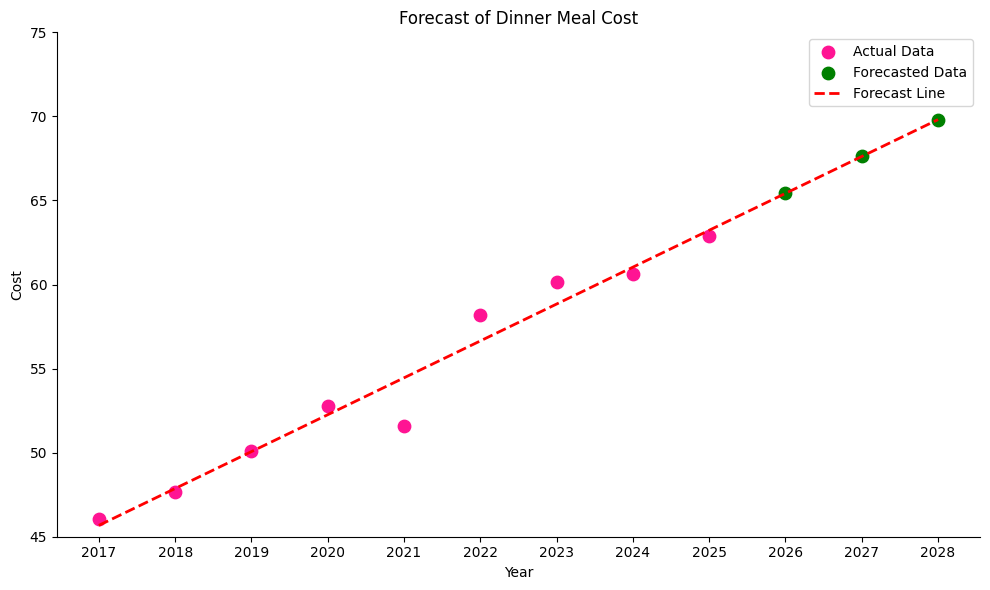

In [3]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [46.07, 47.65, 50.11, 52.80, 51.58,58.18, 60.17, 60.62, 62.88]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Create Continuous Regression Line (Actual + Future Years) ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})
predicted_line = LinReg.predict(all_years)

# --- Step 6: Plot Combined Chart ---
plt.figure(figsize=(10, 6))

# Actual data points (bright pink)
plt.scatter(df['Year'], df['Cost'], color='deeppink', label='Actual Data', s=80)

# Forecasted data points (green)
plt.scatter(future_years['Year'], future_costs, color='green', label='Forecasted Data', s=80)

# Regression line (red dashed)
plt.plot(all_years['Year'], predicted_line, linestyle='--', color='red', linewidth=2, label='Forecast Line')

#print predicted future costs
for year, cost in zip(future_years['Year'], future_costs):
    print(f"Year: {year}, Predicted Cost: {cost:.2f}")
# --- Step 7: Styling ---
plt.ylim(45, 75)
plt.yticks(np.arange(45, 80, 5))
plt.xticks(np.arange(2017, 2029, 1))
plt.title("Forecast of Dinner Meal Cost")
#remove superficial x and y axis lines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


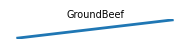

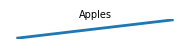

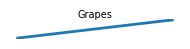

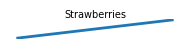

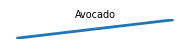

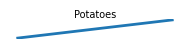

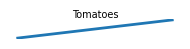

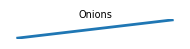

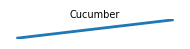

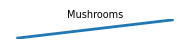

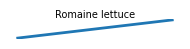

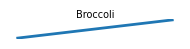

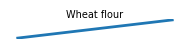

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the Excel file
df = pd.read_excel("HamburgerItemPriceDiffFrom2017to2025.xlsx", sheet_name="Sheet1")

# For each item, create a small sparkline graph
for index, row in df.iterrows():
    item = row['Item']
    
    # Example spike values (2017 → 2025)
    values = [row['Price_2017'], row['Price_2025']]
    
    # Create small figure
    plt.figure(figsize=(2, 0.6))
    
    # Draw spike line
    plt.plot(values, linewidth=2)
    
    # Remove all axes for sparkline effect
    plt.axis('off')
    
    # Add item label to the left
    plt.title(item, fontsize=7, pad=1)
    
    # Tight layout
    plt.tight_layout()
    
    # Show (or save)
    plt.show()
    # To save instead: plt.savefig(f"{item}_sparkline.png", dpi=300, bbox_inches="tight")
    plt.close()


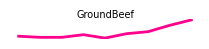

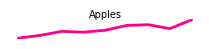

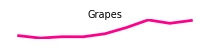

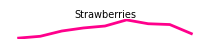

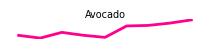

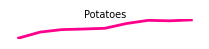

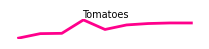

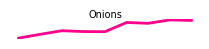

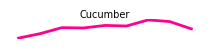

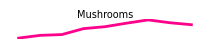

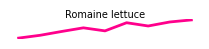

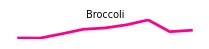

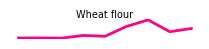

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the Excel file
df = pd.read_excel("HamburgerMenuWithItemsYearlyAverages.xlsx", sheet_name="Sheet1")

# Extract year columns (all columns except the first one)
year_columns = df.columns[1:]  # 2017–2025

# For each item, create a sparkline graph
for index, row in df.iterrows():
    item = row['Items']    # first column is item name
    
    # Get all 2017–2025 values as a list
    values = row[year_columns].tolist()
    
    # Create small sparkline figure
    plt.figure(figsize=(2.2, 0.6))
    
    # Draw spike/sparkline (bright pink)
    plt.plot(values, linewidth=2, color='#ff008c')
    
    # Remove all axes
    plt.axis('off')
    
    # Add item label as title
    plt.title(item, fontsize=7, pad=1)
    
    plt.tight_layout()
    
    # Show (or save)
    plt.show()
    # To save instead:
    # plt.savefig(f"{item}_sparkline.png", dpi=300, bbox_inches='tight')
    plt.close()


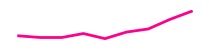

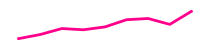

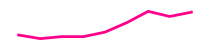

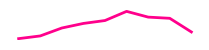

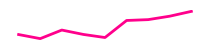

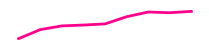

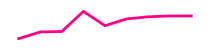

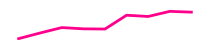

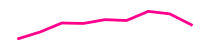

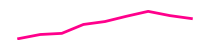

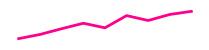

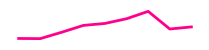

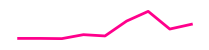

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the Excel file
df = pd.read_excel("HamburgerMenuWithItemsYearlyAverages.xlsx", sheet_name="Sheet1")

# Extract year columns (all columns except the first one)
year_columns = df.columns[1:]  # 2017–2025

# For each item, create a sparkline graph
for index, row in df.iterrows():
    # Get all 2017–2025 values as a list
    values = row[year_columns].tolist()
    
    # Create small sparkline figure
    plt.figure(figsize=(2.2, 0.6))
    
    # Draw spike/sparkline (bright pink)
    plt.plot(values, linewidth=2, color='#ff008c')
    
    # Remove all axes
    plt.axis('off')
    
    plt.tight_layout()
    
    # Show (or save)
    plt.show()
    # To save instead:
    # plt.savefig(f"{row['Items']}_sparkline.png", dpi=300, bbox_inches='tight')
    plt.close()


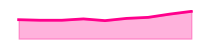

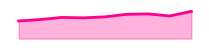

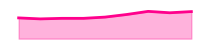

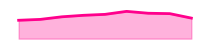

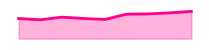

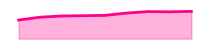

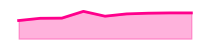

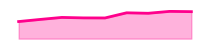

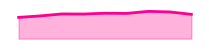

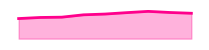

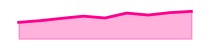

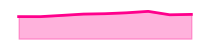

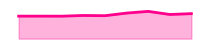

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the Excel file
df = pd.read_excel("HamburgerMenuWithItemsYearlyAverages.xlsx", sheet_name="Sheet1")

# Extract year columns (all columns except the first one)
year_columns = df.columns[1:]  # 2017–2025

# For each item, create a small area sparkline graph
for index, row in df.iterrows():
    # Get all 2017–2025 values as a list
    values = row[year_columns].tolist()
    
    # Create small figure
    plt.figure(figsize=(2.2, 0.6))
    
    # Draw area chart
    plt.plot(values, linewidth=2, color='#ff008c')                # Line
    plt.fill_between(range(len(values)), values, color='#ff008c', alpha=0.3)  # Area under line 

    # Remove all axes
    plt.axis('off')
    
    plt.tight_layout()
    
    # Show (or save)
    plt.show()
    # To save instead:
    # plt.savefig(f"{row['Items']}_area_sparkline.png", dpi=300, bbox_inches='tight')
    plt.close()
